In [138]:
5

5

In [139]:
# import tensorflow as tf

a=tf.constant(5)
print(a)

tf.Tensor(5, shape=(), dtype=int32)


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
import numpy as np

# Data from OPENROCKET

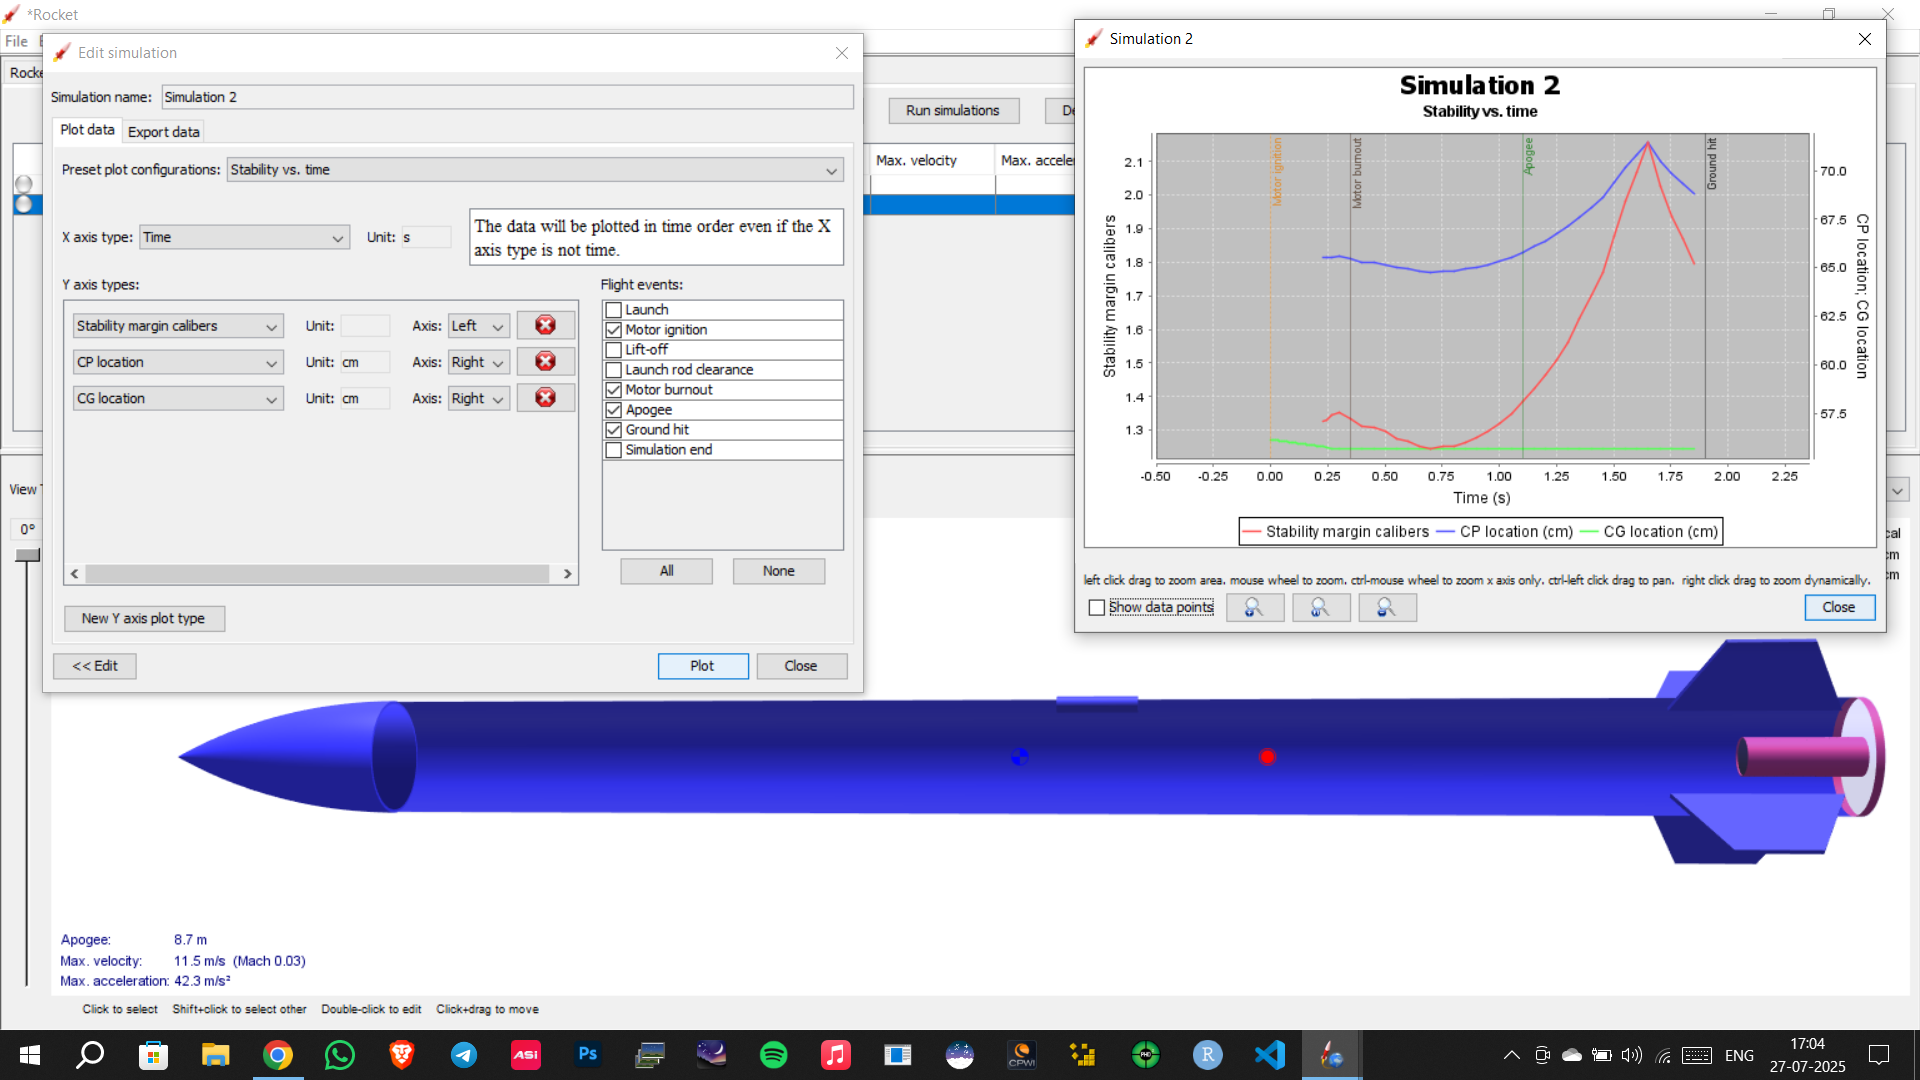

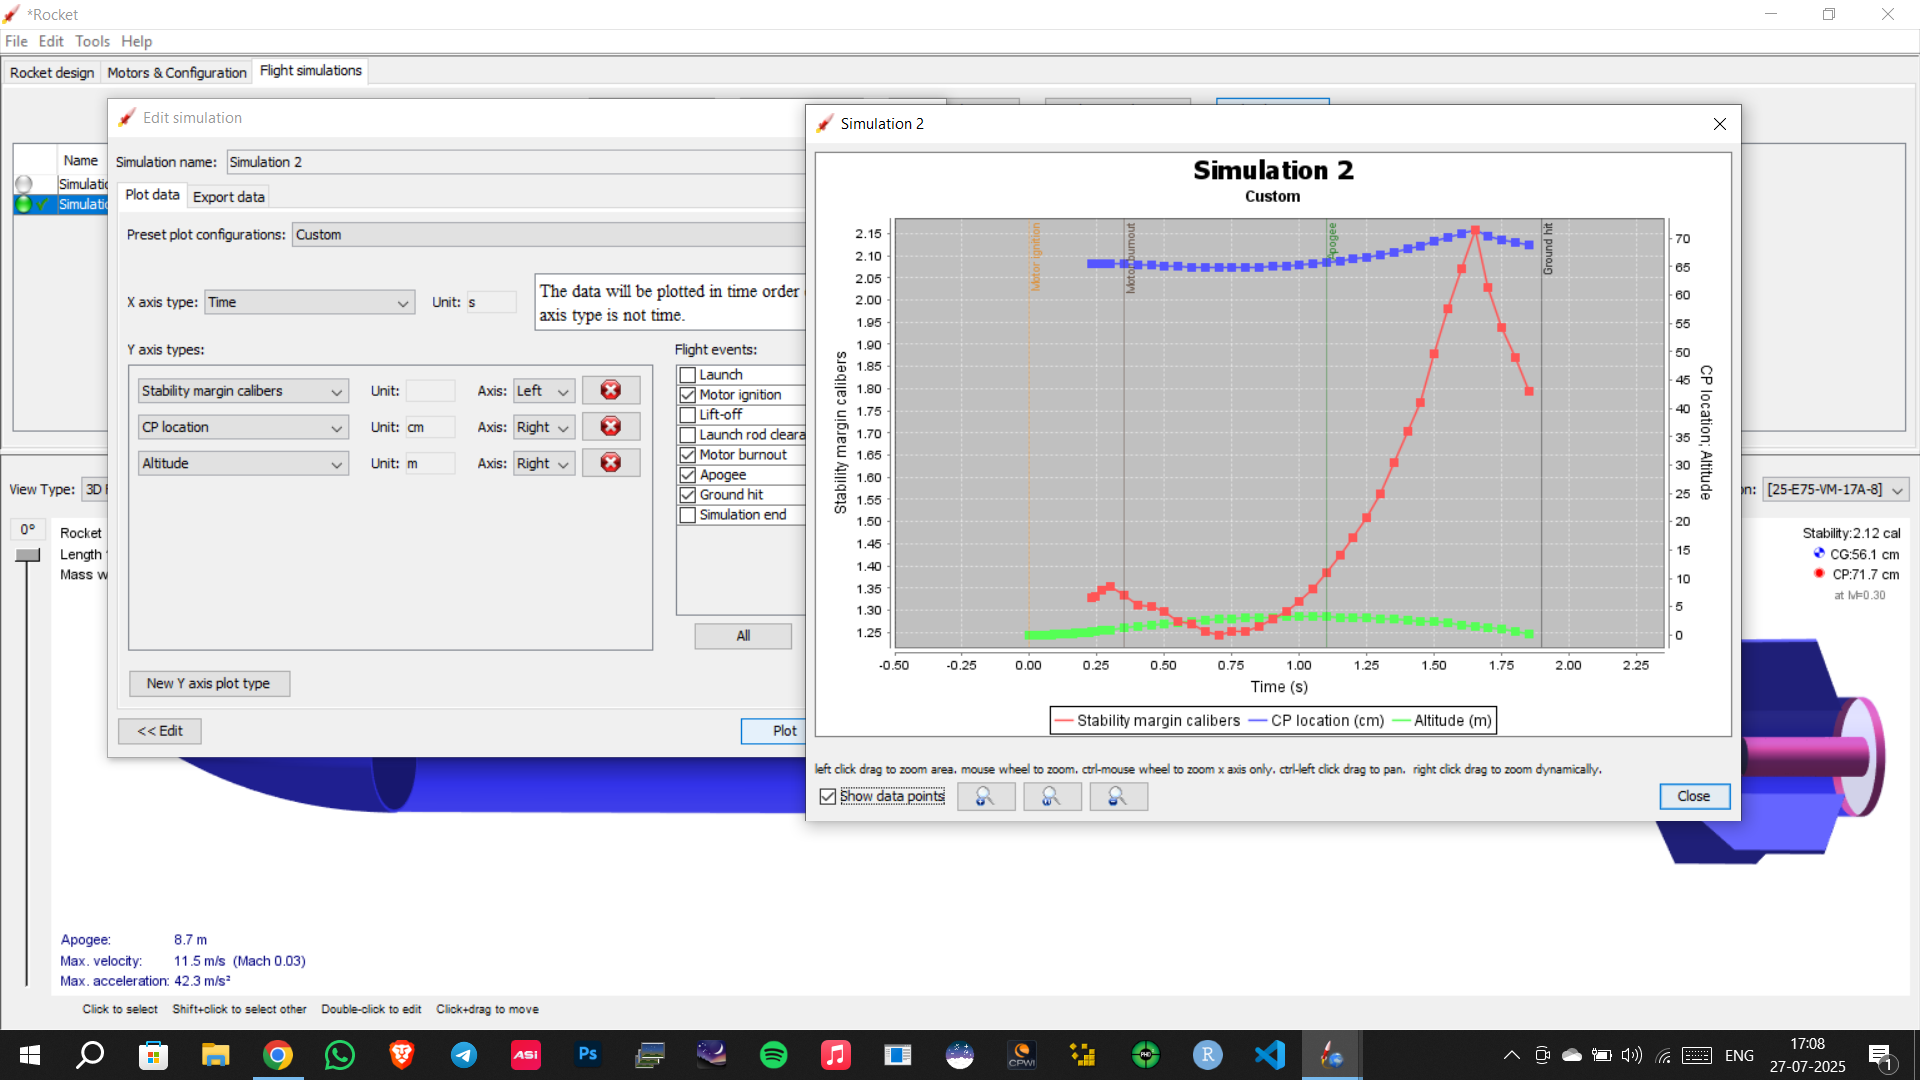

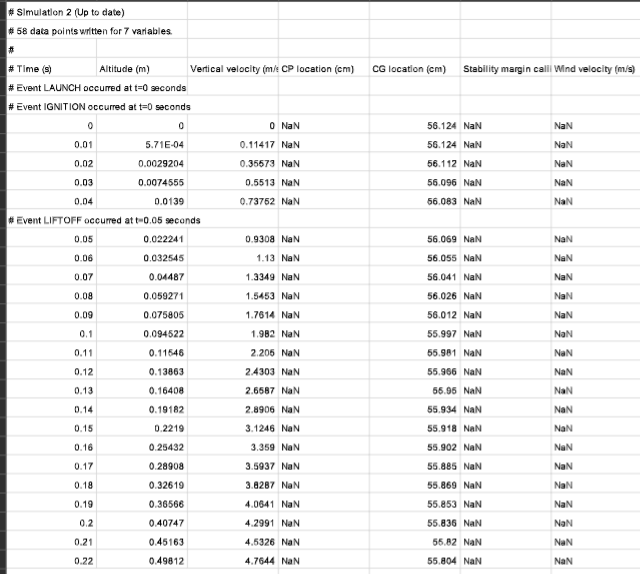

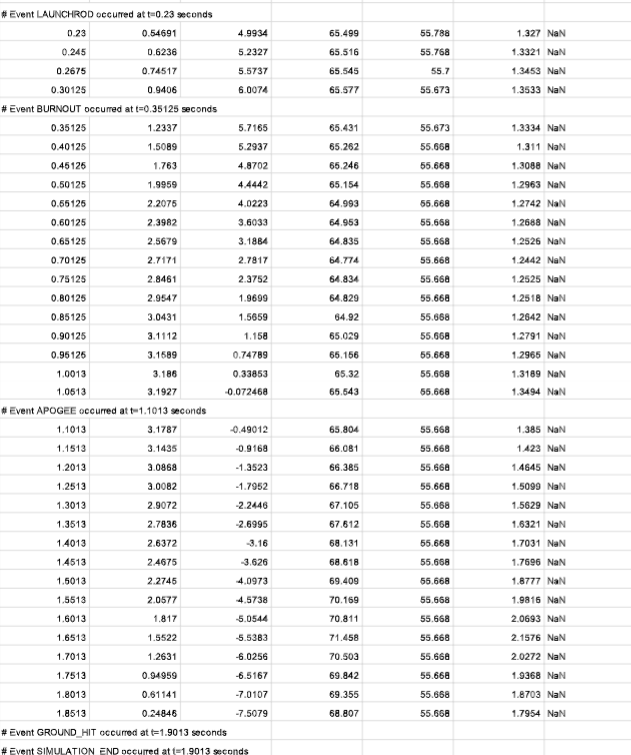

In [141]:
from PIL import Image

a = Image.open("sim1_A.png")
b = Image.open("sim1_b.png")
c = Image.open("op.png")
d = Image.open("plo2.png")

display(c)
display(d)
display(a)
display(b)

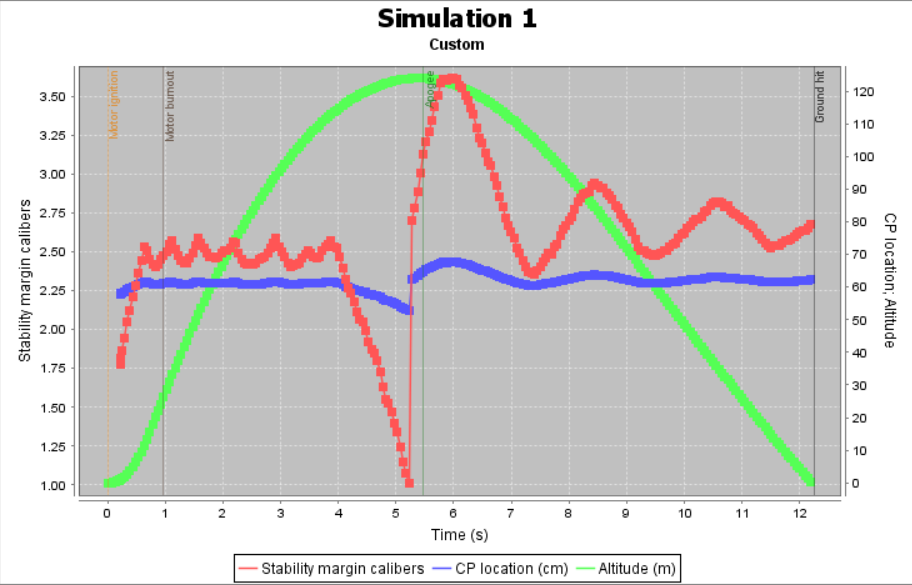

In [142]:
e = Image.open("unstable.png")
display(e)

# Data

In [143]:
import pandas as pd

In [144]:
df = pd.read_csv('rocket_stability_synthetic.csv')

In [145]:
df.head(10)

,rocket_length_cm,rocket_diameter_cm,total_mass_g,motor_type,thrust_N,burn_time_s,wind_speed_mps,angle_of_launch_deg,center_of_mass_cm,center_of_pressure_cm,stability_margin_cm,stable
0,74.94,3.89,671.1,C,80.54,2.26,9.47,77.6,57.48,15.88,-41.60,0
1,144.09,6.56,644.6,A,80.54,3.88,4.06,78.5,68.99,113.13,44.14,1
2,117.84,9.05,1831.3,E,80.54,1.06,3.73,82.4,30.99,68.29,37.30,1
3,101.84,7.99,649.2,F,80.54,3.98,14.13,88.7,87.80,77.64,-10.16,0
4,48.72,8.55,689.5,C,80.54,1.57,4.47,78.2,37.84,63.07,25.23,1
5,48.72,7.44,1566.9,B,80.54,3.55,11.63,77.2,72.47,20.30,-52.17,0
6,36.97,7.69,1009.5,C,80.54,3.05,5.90,86.4,11.45,94.49,83.04,1
7,133.94,8.87,1598.1,C,80.54,4.68,2.09,82.5,43.54,92.19,48.65,1
8,102.13,4.37,317.7,B,80.54,2.24,0.16,88.7,41.65,44.29,2.64,1
9,114.97,6.17,1077.6,D,80.54,0.80,8.16,77.2,58.91,43.69,-15.22,0


In [146]:
print(df.columns)

Index(['rocket_length_cm', 'rocket_diameter_cm', 'total_mass_g', 'motor_type',
       'thrust_N', 'burn_time_s', 'wind_speed_mps', 'angle_of_launch_deg',
       'center_of_mass_cm', 'center_of_pressure_cm', 'stability_margin_cm',
       'stable'],
      dtype='object')


In [147]:
df = df.drop(columns=['stability_margin_cm'])

In [148]:
print(df.columns)

Index(['rocket_length_cm', 'rocket_diameter_cm', 'total_mass_g', 'motor_type',
       'thrust_N', 'burn_time_s', 'wind_speed_mps', 'angle_of_launch_deg',
       'center_of_mass_cm', 'center_of_pressure_cm', 'stable'],
      dtype='object')


In [149]:
# save df as csv
df.to_csv('rocket_stability_synthetic2.csv', index=False)

# Data Augmentation (Increasing data)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# Load data
df = pd.read_csv('rocket_stability_synthetic2.csv')

# Drop 'stability_margin' if present
if 'stability_margin' in df.columns:
    df = df.drop(columns=['stability_margin'])

# Features & target
X = df.drop('stable', axis=1)
y = df['stable']

# Encode categorical features
label_encoders = {}
for col in X.select_dtypes(include='object'):
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Encode target
y_le = LabelEncoder()
y_encoded = y_le.fit_transform(y)

# ---------- SMOTE Upsampling ----------
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y_encoded)

# Combine for synthetic data generation
data = np.hstack([X_smote.values, y_smote.reshape(-1, 1)])

# ---------- Synthetic Data Generator ----------
def generate_synthetic_data(data, n_samples=30000, noise_std=0.01):
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    synthetic = np.random.normal(loc=mean, scale=std + noise_std, size=(n_samples, data.shape[1]))
    return synthetic

# Generate synthetic data
synthetic_data = generate_synthetic_data(data, n_samples=40000)

# Convert to DataFrame
synthetic_df = pd.DataFrame(synthetic_data, columns=list(X.columns) + ['stable'])

# Round and cast categorical columns
for col in synthetic_df.columns:
    if col in label_encoders:
        synthetic_df[col] = synthetic_df[col].round().astype(int)
        # Ensure values are within original label range
        le = label_encoders[col]
        synthetic_df[col] = np.clip(synthetic_df[col], 0, len(le.classes_) - 1)
        synthetic_df[col] = le.inverse_transform(synthetic_df[col])

# Clip & decode stable
synthetic_df['stable'] = synthetic_df['stable'].round().astype(int)
synthetic_df['stable'] = np.clip(synthetic_df['stable'], 0, len(y_le.classes_) - 1)
synthetic_df['stable'] = y_le.inverse_transform(synthetic_df['stable'])

# Save
synthetic_df.to_csv('synthetic_rocket_data_final.csv', index=False)
print("✅ Synthetic data with SMOTE + noise saved as 'synthetic_rocket_data_final.csv'")


In [ ]:
df = pd.read_csv('synthetic_rocket_data_final.csv')

In [ ]:
df

,rocket_length_cm,rocket_diameter_cm,total_mass_g,motor_type,thrust_N,burn_time_s,wind_speed_mps,angle_of_launch_deg,center_of_mass_cm,center_of_pressure_cm,stable
0,92.263965,7.318445,1558.409471,C,80.548550,3.685192,7.900708,77.322137,41.435541,76.336374,1
1,62.308725,5.260887,1855.838072,D,80.532376,2.165382,2.260100,77.355466,42.209006,44.720336,1
2,70.095137,5.693726,1201.898817,A,80.540915,4.321786,4.416657,81.395239,32.303891,66.886355,0
3,-9.311190,10.105686,1124.177361,F,80.546407,2.923647,-1.217843,84.470204,44.575588,83.873806,1
4,103.513440,9.464406,408.301735,A,80.531871,0.932922,1.109980,82.601417,55.866612,53.397198,1
...,...,...,...,...,...,...,...,...,...,...,...
39995,86.242345,4.688203,680.230550,A,80.555056,3.834755,10.785475,94.188370,51.949320,47.337977,1
39996,80.870142,4.695159,1353.294125,E,80.524984,2.090799,8.133564,82.236184,14.831067,67.905293,1
39997,55.977253,5.906496,1466.209320,E,80.539640,3.818635,9.905695,77.783814,55.223684,50.863000,0
39998,71.697747,6.859295,670.755675,D,80.531782,-0.207342,11.024152,81.427402,101.299050,90.768573,0


In [ ]:
df['stable'].value_counts()

stable
1    20027
0    19973
Name: count, dtype: int64

In [ ]:
# print first row
print(df.iloc[0])

rocket_length_cm           92.263965
rocket_diameter_cm          7.318445
total_mass_g             1558.409471
motor_type                         C
thrust_N                    80.54855
burn_time_s                 3.685192
wind_speed_mps              7.900708
angle_of_launch_deg        77.322137
center_of_mass_cm          41.435541
center_of_pressure_cm      76.336374
stable                             1
Name: 0, dtype: object


In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Add Gaussian noise to CM and CP (mean=0, std=1.0 cm)
df['center_of_mass_cm'] += np.random.normal(0, 1.0, df.shape[0])
df['center_of_pressure_cm'] += np.random.normal(0, 1.0, df.shape[0])

# Optional: Clip to ensure realistic values (assuming range ~ 10 to 100 cm)
df['center_of_mass_cm'] = df['center_of_mass_cm'].clip(10, 100)
df['center_of_pressure_cm'] = df['center_of_pressure_cm'].clip(10, 100)

# Save final dataset
df.to_csv("rocket_data_final.csv", index=False)


In [ ]:
df = pd.read_csv('rocket_data_final.csv')

In [ ]:
df

,rocket_length_cm,rocket_diameter_cm,total_mass_g,motor_type,thrust_N,burn_time_s,wind_speed_mps,angle_of_launch_deg,center_of_mass_cm,center_of_pressure_cm,stable
0,92.263965,7.318445,1558.409471,C,80.548550,3.685192,7.900708,77.322137,41.932255,75.864517,1
1,62.308725,5.260887,1855.838072,D,80.532376,2.165382,2.260100,77.355466,42.070742,45.733038,1
2,70.095137,5.693726,1201.898817,A,80.540915,4.321786,4.416657,81.395239,32.951579,66.688168,0
3,-9.311190,10.105686,1124.177361,F,80.546407,2.923647,-1.217843,84.470204,46.098618,83.964375,1
4,103.513440,9.464406,408.301735,A,80.531871,0.932922,1.109980,82.601417,55.632458,54.114589,1
...,...,...,...,...,...,...,...,...,...,...,...
39995,86.242345,4.688203,680.230550,A,80.555056,3.834755,10.785475,94.188370,53.068971,48.278842,1
39996,80.870142,4.695159,1353.294125,E,80.524984,2.090799,8.133564,82.236184,15.096101,67.475974,1
39997,55.977253,5.906496,1466.209320,E,80.539640,3.818635,9.905695,77.783814,55.840185,50.394043,0
39998,71.697747,6.859295,670.755675,D,80.531782,-0.207342,11.024152,81.427402,100.000000,90.765230,0


In [ ]:
print(df.head(7))

   rocket_length_cm  rocket_diameter_cm  total_mass_g motor_type   thrust_N  \
0         92.263965            7.318445   1558.409471          C  80.548550   
1         62.308725            5.260887   1855.838072          D  80.532376   
2         70.095137            5.693726   1201.898817          A  80.540915   
3         -9.311190           10.105686   1124.177361          F  80.546407   
4        103.513440            9.464406    408.301735          A  80.531871   
5        112.268096            5.575704   1252.233174          E  80.530213   
6        152.796008            3.828751    817.875375          A  80.561411   

   burn_time_s  wind_speed_mps  angle_of_launch_deg  center_of_mass_cm  \
0     3.685192        7.900708            77.322137          41.932255   
1     2.165382        2.260100            77.355466          42.070742   
2     4.321786        4.416657            81.395239          32.951579   
3     2.923647       -1.217843            84.470204          46.098618 

# DATA 2

In [41]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Motor types and thrust ranges (realistic synthetic ranges per motor class)
motor_types = {
    'A': (10, 20),
    'B': (20, 40),
    'C': (40, 80),
    'D': (80, 160),
    'E': (160, 320)
}

def generate_motor_onehot_and_thrust():
    motor = np.random.choice(list(motor_types.keys()))
    one_hot = {f'motor_type_{m}': int(m == motor) for m in motor_types}
    thrust = np.random.uniform(*motor_types[motor])
    return one_hot, thrust

def generate_sample():
    length = np.random.uniform(50, 120)                 # cm
    diameter = np.random.uniform(3, 8)                  # cm
    mass = np.random.uniform(500, 2000)                 # g
    one_hot, thrust = generate_motor_onehot_and_thrust()
    burn_time = np.random.uniform(0.5, 3.0)             # s
    wind_speed = np.random.uniform(0, 10)               # m/s
    launch_angle = np.random.uniform(60, 90)            # degrees
    com = np.random.uniform(0.3 * length, 0.7 * length) # center of mass
    cop = np.random.uniform(0.5 * length, 0.9 * length) # center of pressure
    
    # Determine stability: simple logic (stable if CP > COM and angle close to vertical)
    stable = int((cop - com > 5) and (launch_angle >= 75))
    
    sample = {
        'rocket_length_cm': length,
        'rocket_diameter_cm': diameter,
        'total_mass_g': mass,
        'thrust_N': thrust,
        'burn_time_s': burn_time,
        'wind_speed_mps': wind_speed,
        'angle_of_launch_deg': launch_angle,
        'center_of_mass_cm': com,
        'center_of_pressure_cm': cop,
        'stable': stable
    }
    
    sample.update(one_hot)
    return sample

# Generate dataset
data = [generate_sample() for _ in range(10000)]
df = pd.DataFrame(data)

# Optional: Verify only one motor type per row
assert (df[[f'motor_type_{m}' for m in motor_types]].sum(axis=1) == 1).all(), "Motor type encoding error!"



In [42]:
df

,rocket_length_cm,rocket_diameter_cm,total_mass_g,thrust_N,burn_time_s,wind_speed_mps,angle_of_launch_deg,center_of_mass_cm,center_of_pressure_cm,stable,motor_type_A,motor_type_B,motor_type_C,motor_type_D,motor_type_E
0,76.217808,7.753572,1597.990913,255.496025,1.614582,0.999749,73.777467,33.039158,42.464502,0,0,0,0,0,1
1,95.562193,3.282058,1582.998158,23.636499,0.958511,3.042422,75.742693,45.179703,58.913295,1,0,1,0,0,0
2,92.829703,3.697469,938.216973,55.298480,2.958077,4.667629,85.798212,53.110009,63.142736,1,0,0,1,0,0
3,50.928547,7.711009,1344.932327,26.092275,0.744180,6.842330,73.204575,17.764656,35.551730,0,0,1,0,0,0
4,52.407196,7.546602,888.169972,104.936886,1.800170,5.467103,65.545634,36.047444,42.452614,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,108.011897,3.170849,1230.786183,15.733399,2.820106,5.144697,76.912177,70.389129,80.566324,1,1,0,0,0,0
9996,80.631102,4.267859,1948.243929,86.622420,0.813281,2.053585,67.108907,44.994736,57.505843,0,0,0,0,1,0
9997,66.506719,3.747995,1537.689392,97.539454,1.239315,1.812890,77.222585,39.029368,44.090518,1,0,0,0,1,0
9998,61.663570,5.006991,1198.829025,245.052965,0.643087,9.781837,65.662395,31.531620,39.251865,0,0,0,0,0,1


In [43]:
df.to_csv("data_final.csv", index=False)

In [44]:
df['stable'].value_counts()

stable
0    6007
1    3993
Name: count, dtype: int64

In [46]:
# DONE IN COLAB

In [47]:
df = pd.read_csv('rocket.csv')

In [48]:
df.head()

,rocket_length_cm,rocket_diameter_cm,total_mass_g,thrust_N,burn_time_s,wind_speed_mps,angle_of_launch_deg,center_of_mass_cm,center_of_pressure_cm,motor_type_A,motor_type_B,motor_type_C,motor_type_D,motor_type_E,stable
0,76.217808,7.753572,1597.990913,255.496025,1.614582,0.999749,73.777467,33.039158,42.464502,0,0,0,0,1,0
1,95.562193,3.282058,1582.998158,23.636499,0.958511,3.042422,75.742693,45.179703,58.913295,0,1,0,0,0,1
2,92.829703,3.697469,938.216973,55.298480,2.958077,4.667629,85.798212,53.110009,63.142736,0,0,1,0,0,1
3,50.928547,7.711009,1344.932327,26.092275,0.744180,6.842330,73.204575,17.764656,35.551730,0,1,0,0,0,0
4,52.407196,7.546602,888.169972,104.936886,1.800170,5.467103,65.545634,36.047444,42.452614,0,0,0,1,0,0


In [49]:
df['stable'].value_counts()

stable
0    6007
1    6007
Name: count, dtype: int64

# DATA 3

In [24]:
df = pd.read_csv('rocket3.csv')

In [25]:
print(df.iloc[0:10])

   Unnamed: 0  length  diameter    mass  motor_thrust  burn_time     cg  \
0           0   63.71      4.30   540.2         141.1       1.93  30.50   
1           1  115.56      6.79   521.1         163.4       2.51  57.17   
2           2   95.88      9.11  1378.1          65.1       2.40  54.74   
3           3   83.88      8.13   524.4         132.5       0.88  39.26   
4           4   44.04      8.65   553.5         122.9       0.87  25.28   
5           5   44.04      7.61  1187.2         169.9       1.17  18.39   
6           6   35.23      7.85   784.7         183.1       1.40  19.56   
7           7  107.96      8.94  1209.7          22.2       1.52  61.48   
8           8   84.10      4.75   285.0         141.3       2.20  36.70   
9           9   93.73      6.43   833.8          29.3       0.64  45.56   

      cp  material  stable  
0  50.62       2.0       1  
1  75.32       0.0       1  
2  82.62       2.0       1  
3  65.76       2.0       1  
4  28.50       0.0       0  


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import BorderlineSMOTE


X = df.drop('stable', axis=1)
y = df['stable']

# Step 2: Apply Borderline SMOTE to balance class 0 and 1
sm = BorderlineSMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

# Convert back to DataFrame
df_balanced = pd.DataFrame(X_res, columns=X.columns)
df_balanced['stable'] = y_res

# Step 3: Define a function to apply light Gaussian noise to numeric features
def add_noise(df, std_dev=0.5):
    df_noisy = df.copy()
    numeric_cols = df_noisy.select_dtypes(include=[np.number]).columns.drop('stable')
    for col in numeric_cols:
        noise = np.random.normal(0, std_dev, size=len(df_noisy))
        df_noisy[col] += noise
    return df_noisy

# Step 4: Augment to 10,000 samples
target_len = 10000
df_aug = df_balanced.copy()

while len(df_aug) < target_len:
    # Sample 1000 rows and add noise
    df_sample = df_balanced.sample(n=1000, replace=True, random_state=np.random.randint(1000))
    df_noisy = add_noise(df_sample, std_dev=0.3)

    # Fix CG < CP rule
    mask = df_noisy['cg'] >= df_noisy['cp']
    df_noisy.loc[mask, 'cp'] = df_noisy.loc[mask, 'cg'] + np.random.uniform(4, 8, size=mask.sum())

    # Append
    df_aug = pd.concat([df_aug, df_noisy], ignore_index=True)

df_aug = df_aug.iloc[:10000]

In [30]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [31]:
df.head()

,length,diameter,mass,motor_thrust,burn_time,cg,cp,material,stable
0,63.71,4.30,540.2,141.1,1.93,30.50,50.62,2.0,1
1,115.56,6.79,521.1,163.4,2.51,57.17,75.32,0.0,1
2,95.88,9.11,1378.1,65.1,2.40,54.74,82.62,2.0,1
3,83.88,8.13,524.4,132.5,0.88,39.26,65.76,2.0,1
4,44.04,8.65,553.5,122.9,0.87,25.28,28.50,0.0,0


In [32]:
df.shape

(10000, 9)

# Data Preparation

In [ ]:
import pandas as pd

In [33]:
df = pd.read_csv('rocket3.csv')

In [ ]:
# #encode motor_type 
# from sklearn.preprocessing import LabelEncoder
# fit_transform = LabelEncoder().fit_transform
# df['motor_type'] = fit_transform(df['motor_type'])

In [51]:
df.head()

,rocket_length_cm,rocket_diameter_cm,total_mass_g,thrust_N,burn_time_s,wind_speed_mps,angle_of_launch_deg,center_of_mass_cm,center_of_pressure_cm,motor_type_A,motor_type_B,motor_type_C,motor_type_D,motor_type_E,stable
0,76.217808,7.753572,1597.990913,255.496025,1.614582,0.999749,73.777467,33.039158,42.464502,0,0,0,0,1,0
1,95.562193,3.282058,1582.998158,23.636499,0.958511,3.042422,75.742693,45.179703,58.913295,0,1,0,0,0,1
2,92.829703,3.697469,938.216973,55.298480,2.958077,4.667629,85.798212,53.110009,63.142736,0,0,1,0,0,1
3,50.928547,7.711009,1344.932327,26.092275,0.744180,6.842330,73.204575,17.764656,35.551730,0,1,0,0,0,0
4,52.407196,7.546602,888.169972,104.936886,1.800170,5.467103,65.545634,36.047444,42.452614,0,0,0,1,0,0


In [ ]:
# from sklearn.impute import KNNImputer

# # replace negatives with NaN first
# for col in numerical_cols:
#     df[col] = df[col].apply(lambda x: np.nan if x < 0 else x)

# imputer = KNNImputer(n_neighbors=5)
# df[numerical_cols] = imputer.fit_transform(df[numerical_cols])


In [52]:
#use min max scaler
from sklearn.preprocessing import MinMaxScaler

numerical_cols = [
    'rocket_length_cm', 'rocket_diameter_cm', 'total_mass_g', 'thrust_N',
    'burn_time_s', 'wind_speed_mps', 'angle_of_launch_deg',
    'center_of_mass_cm', 'center_of_pressure_cm'
]

scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])


In [53]:
df.head()

,rocket_length_cm,rocket_diameter_cm,total_mass_g,thrust_N,burn_time_s,wind_speed_mps,angle_of_launch_deg,center_of_mass_cm,center_of_pressure_cm,motor_type_A,motor_type_B,motor_type_C,motor_type_D,motor_type_E,stable
0,0.374527,0.950867,0.732064,0.792182,0.445884,0.099905,0.459248,0.264694,0.206934,0,0,0,0,1,0
1,0.650951,0.056265,0.722068,0.044003,0.183357,0.304220,0.524757,0.443870,0.408309,0,1,0,0,0,1
2,0.611905,0.139375,0.292163,0.146172,0.983483,0.466779,0.859946,0.560909,0.460089,0,0,1,0,0,1
3,0.013153,0.942351,0.563338,0.051927,0.097593,0.684300,0.440151,0.039265,0.122303,0,1,0,0,0,0
4,0.034283,0.909459,0.258794,0.306348,0.520147,0.546745,0.184849,0.309091,0.206788,0,0,0,1,0,0


In [54]:
print(df.iloc[0])

rocket_length_cm         0.374527
rocket_diameter_cm       0.950867
total_mass_g             0.732064
thrust_N                 0.792182
burn_time_s              0.445884
wind_speed_mps           0.099905
angle_of_launch_deg      0.459248
center_of_mass_cm        0.264694
center_of_pressure_cm    0.206934
motor_type_A             0.000000
motor_type_B             0.000000
motor_type_C             0.000000
motor_type_D             0.000000
motor_type_E             1.000000
stable                   0.000000
Name: 0, dtype: float64


# Visualization

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
df = pd.read_csv('rocket.csv')

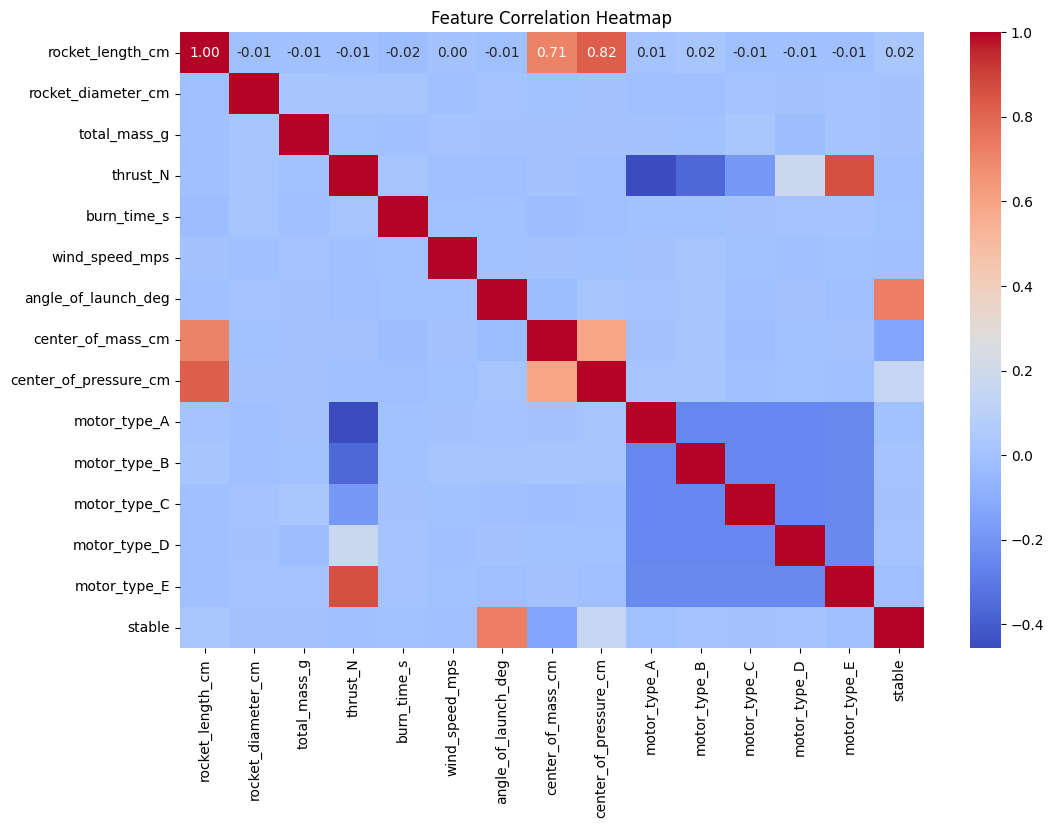

In [57]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

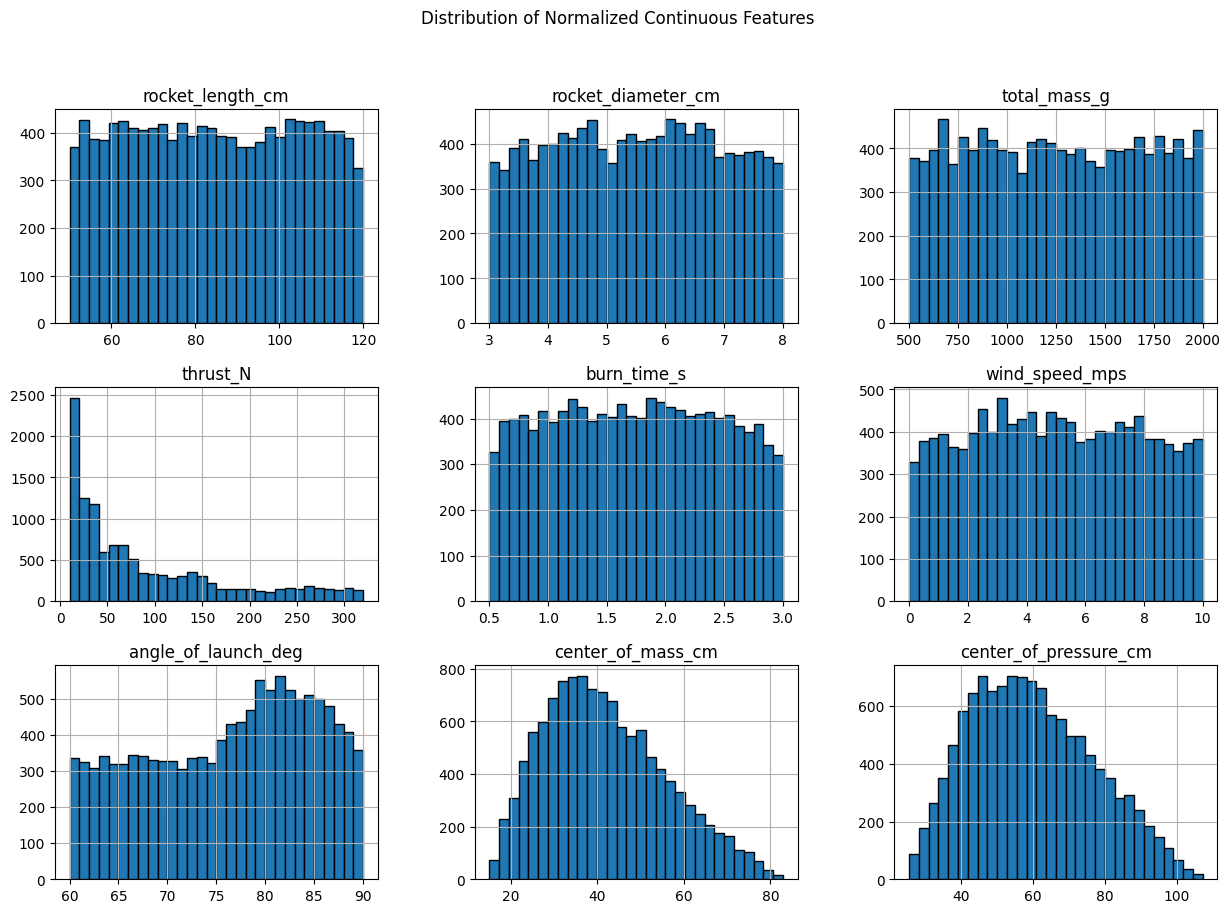

In [58]:
continuous = ['rocket_length_cm', 'rocket_diameter_cm', 'total_mass_g',
              'thrust_N', 'burn_time_s', 'wind_speed_mps',
              'angle_of_launch_deg', 'center_of_mass_cm', 'center_of_pressure_cm']

df[continuous].hist(bins=30, figsize=(15, 10), edgecolor='black')
plt.suptitle("Distribution of Normalized Continuous Features")
plt.show()

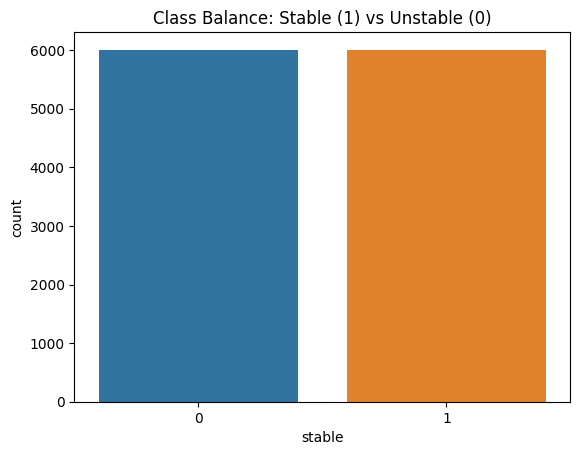

Class distribution:
 stable
0    6007
1    6007
Name: count, dtype: int64


In [59]:
sns.countplot(data=df, x='stable')
plt.title("Class Balance: Stable (1) vs Unstable (0)")
plt.show()
print("Class distribution:\n", df['stable'].value_counts())

c:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 t

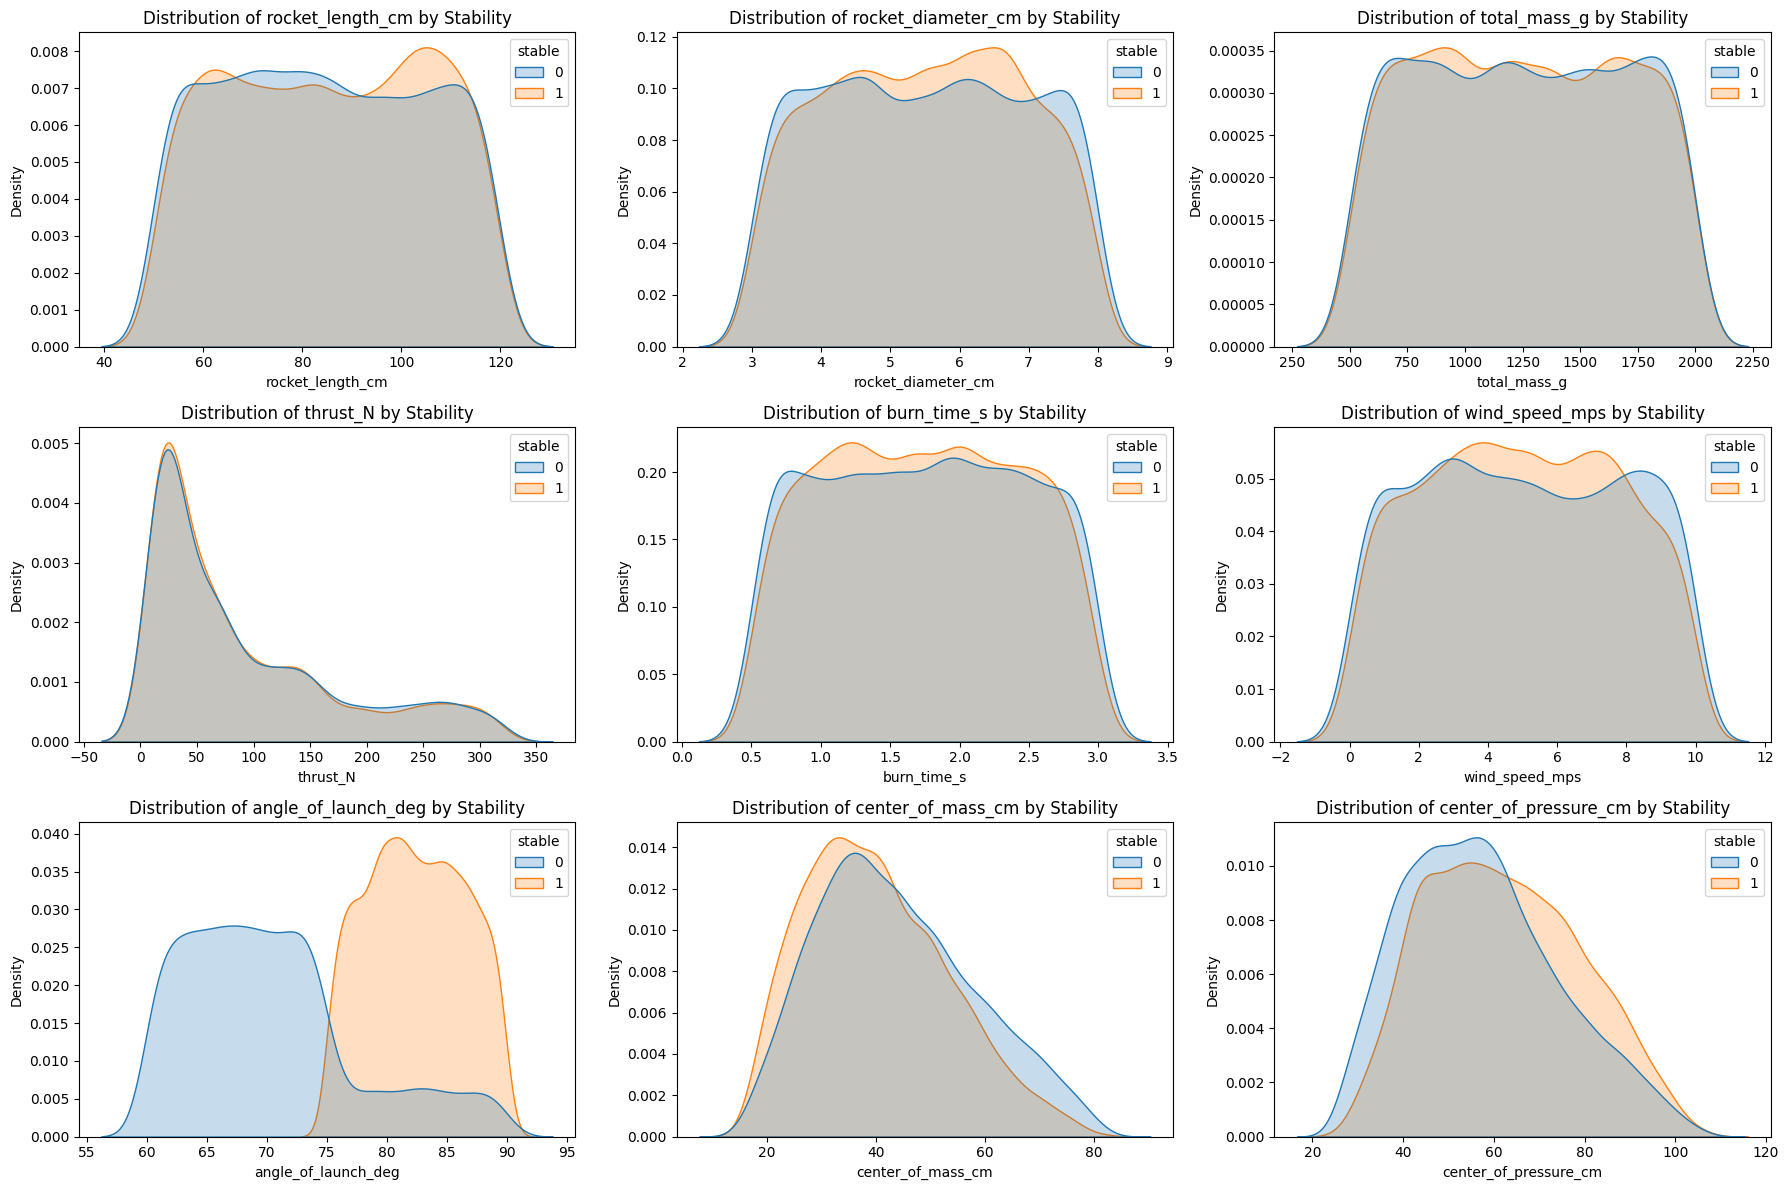

Feature distributions by stability class visualized.


In [60]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Number of plots
n = len(continuous)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(cols * 6, rows * 4))

for idx, col in enumerate(continuous):
    plt.subplot(rows, cols, idx + 1)
    sns.kdeplot(data=df, x=col, hue='stable', fill=True)
    plt.title(f'Distribution of {col} by Stability')
    plt.xlabel(col)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()
print("Feature distributions by stability class visualized.")


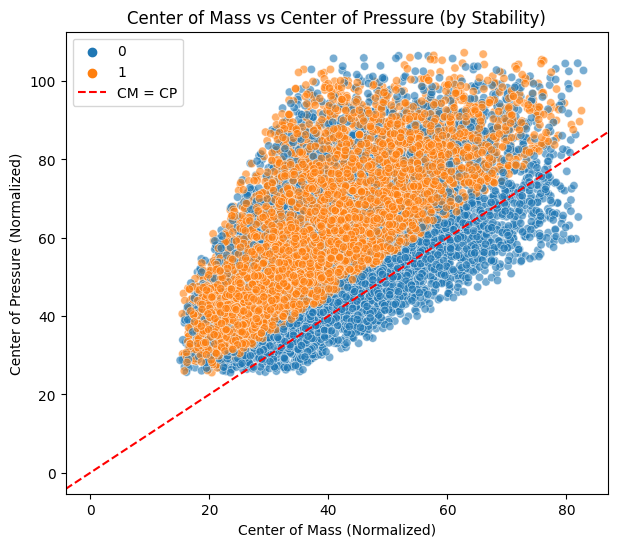

In [61]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x='center_of_mass_cm', y='center_of_pressure_cm', hue='stable', alpha=0.6)
plt.axline((0, 0), slope=1, color='red', linestyle='--', label='CM = CP')
plt.title("Center of Mass vs Center of Pressure (by Stability)")
plt.legend()
plt.xlabel("Center of Mass (Normalized)")
plt.ylabel("Center of Pressure (Normalized)")
plt.show()

# Modelling - Data2

In [35]:
df = pd.read_csv('rocket.csv')

In [36]:
df.shape

(12014, 15)

In [37]:
#use min max scaler
from sklearn.preprocessing import MinMaxScaler

numerical_cols = [
    'rocket_length_cm', 'rocket_diameter_cm', 'total_mass_g', 'thrust_N',
    'burn_time_s', 'wind_speed_mps', 'angle_of_launch_deg',
    'center_of_mass_cm', 'center_of_pressure_cm'
]

scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [7]:
df.head(2)

,rocket_length_cm,rocket_diameter_cm,total_mass_g,thrust_N,burn_time_s,wind_speed_mps,angle_of_launch_deg,center_of_mass_cm,center_of_pressure_cm,motor_type_A,motor_type_B,motor_type_C,motor_type_D,motor_type_E,stable
0,0.374527,0.950867,0.732064,0.792182,0.445884,0.099905,0.459248,0.264694,0.206934,0,0,0,0,1,0
1,0.650951,0.056265,0.722068,0.044003,0.183357,0.304220,0.524757,0.443870,0.408309,0,1,0,0,0,1


In [38]:
from sklearn.model_selection import train_test_split

x = df.drop(columns=['stable'])
y = df['stable']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

x = df.drop('stable', axis=1)
y = df['stable']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(x_train, y_train)

y_pred = clf.predict(x_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99      1206
           1       0.98      1.00      0.99      1197

    accuracy                           0.99      2403
   macro avg       0.99      0.99      0.99      2403
weighted avg       0.99      0.99      0.99      2403

Confusion Matrix:
 [[1183   23]
 [   3 1194]]


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9891801914273824
Precision: 0.981101068200493
Recall: 0.9974937343358395
F1 Score: 0.9892294946147473


In [11]:
# print real and predicted values
print("Real values:\n", y_test.values)
print("Predicted values:\n", y_pred)
print("Predicted probabilities:\n", clf.predict_proba(x_test))


Real values:
 [1 0 1 ... 0 0 0]
Predicted values:
 [1 0 1 ... 0 0 0]
Predicted probabilities:
 [[0.2  0.8 ]
 [1.   0.  ]
 [0.12 0.88]
 ...
 [0.99 0.01]
 [0.99 0.01]
 [0.98 0.02]]


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(64, input_shape=(x_train.shape[1],), activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
             loss='binary_crossentropy',
             metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    validation_data=(x_test, y_test),
                    epochs=30,
                    batch_size=32)

Epoch 1/30


c:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7636 - loss: 0.5010 - val_accuracy: 0.8781 - val_loss: 0.2780
Epoch 2/30
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8879 - loss: 0.2576 - val_accuracy: 0.8918 - val_loss: 0.2315
Epoch 3/30
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step - accuracy: 0.9066 - loss: 0.2124 - val_accuracy: 0.9384 - val_loss: 0.1477
Epoch 4/30
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 994us/step - accuracy: 0.9502 - loss: 0.1245 - val_accuracy: 0.9613 - val_loss: 0.1000
Epoch 5/30
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9690 - loss: 0.0823 - val_accuracy: 0.9771 - val_loss: 0.0598
Epoch 6/30
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 881us/step - accuracy: 0.9735 - loss: 0.0650 - val_accuracy: 0.9621 - val_loss: 0.0879
Epoch 7/30
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step - accuracy: 0.9721 - loss: 0.0658 - val_accuracy: 0.9742 - val_loss: 0.0628
Epoch 8/30
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step - accuracy: 0.9779 - loss: 0.0516 - val_accuracy: 0.9

In [14]:
model.evaluate(x_test, y_test)

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 889us/step - accuracy: 0.9901 - loss: 0.0255


[0.03267182782292366, 0.9866833090782166]

In [16]:
model.save('models/model1_98_03.h5')

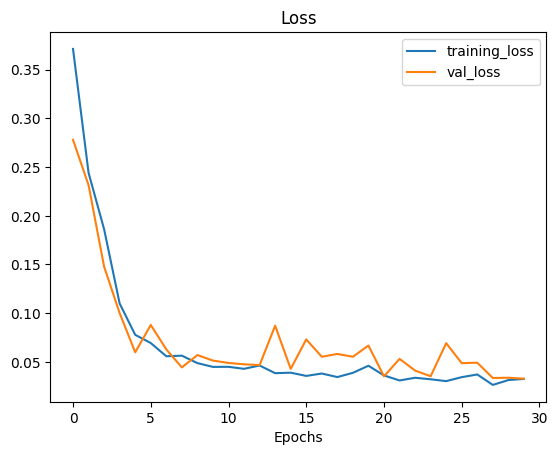

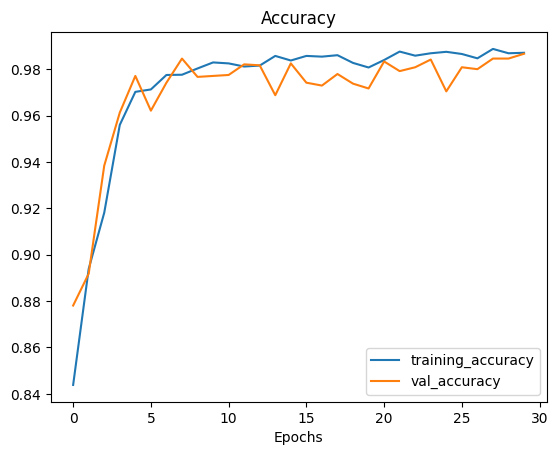

In [13]:
from helper_functions import *

plot_loss_curves(history)

## Improving



-- Can be improved by --
1) Adding more layers
2) Change the optimizer
3) Add More Epoches
4) Increase hidden layers
5) Change the learning rate
6) Fitting more data

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(100, input_shape=(x_train.shape[1],), activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
             loss='binary_crossentropy',
             metrics=['accuracy'])

history2 = model.fit(x_train, y_train,
                    validation_data=(x_test, y_test),
                    epochs=30,
                    batch_size=32)

Epoch 1/30


c:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7904 - loss: 0.4808 - val_accuracy: 0.8893 - val_loss: 0.2484
Epoch 2/30
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9031 - loss: 0.2300 - val_accuracy: 0.9272 - val_loss: 0.1629
Epoch 3/30
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9467 - loss: 0.1326 - val_accuracy: 0.9501 - val_loss: 0.1103
Epoch 4/30
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9642 - loss: 0.0852 - val_accuracy: 0.9700 - val_loss: 0.0674
Epoch 5/30
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9761 - loss: 0.0618 - val_accuracy: 0.9792 - val_loss: 0.0555
Epoch 6/30
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9781 - loss: 0.0568 - val_accuracy: 0.9663 - val_loss: 0.0778
Epoch 7/30
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step - accuracy: 0.9738 - loss: 0.0587 - val_accuracy: 0.9750 - val_loss: 0.0538
Epoch 8/30
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9781 - loss: 0.0511 - val_accuracy: 0.9767 - va

In [41]:
model.evaluate(x_test, y_test)

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 442us/step - accuracy: 0.9865 - loss: 0.0325


[0.032332371920347214, 0.9875156283378601]

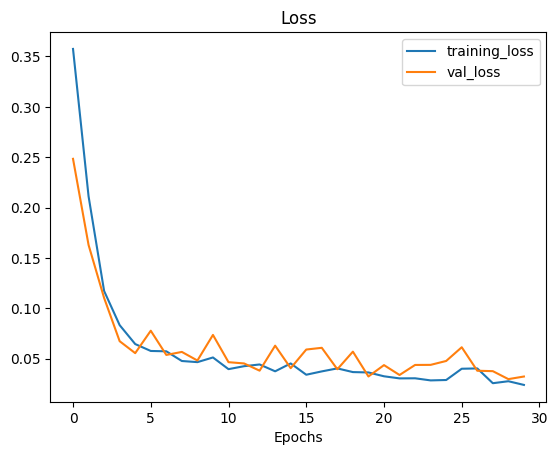

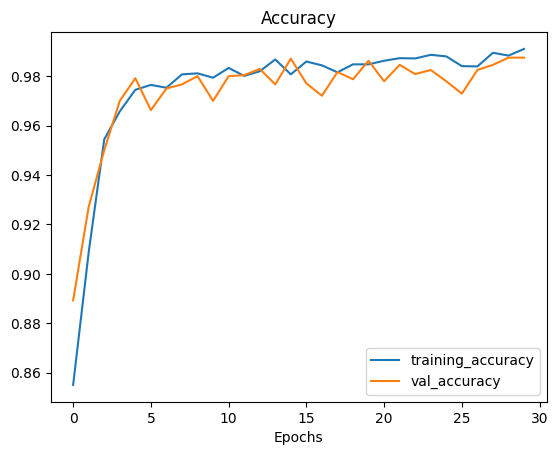

In [40]:
plot_loss_curves(history2)

# Modelling - Data 3

In [45]:
df2 = pd.read_csv('rocket3.csv')
df2.drop(columns=['Unnamed: 0'], inplace=True)

In [46]:
df2.head()

,length,diameter,mass,motor_thrust,burn_time,cg,cp,material,stable
0,63.71,4.30,540.2,141.1,1.93,30.50,50.62,2.0,1
1,115.56,6.79,521.1,163.4,2.51,57.17,75.32,0.0,1
2,95.88,9.11,1378.1,65.1,2.40,54.74,82.62,2.0,1
3,83.88,8.13,524.4,132.5,0.88,39.26,65.76,2.0,1
4,44.04,8.65,553.5,122.9,0.87,25.28,28.50,0.0,0


In [62]:
df2

,length,diameter,mass,motor_thrust,burn_time,cg,cp,material,stable
0,63.710000,4.300000,540.200000,141.100000,1.930000,30.500000,50.620000,2.000000,1
1,115.560000,6.790000,521.100000,163.400000,2.510000,57.170000,75.320000,0.000000,1
2,95.880000,9.110000,1378.100000,65.100000,2.400000,54.740000,82.620000,2.000000,1
3,83.880000,8.130000,524.400000,132.500000,0.880000,39.260000,65.760000,2.000000,1
4,44.040000,8.650000,553.500000,122.900000,0.870000,25.280000,28.500000,0.000000,0
...,...,...,...,...,...,...,...,...,...
9995,43.142391,5.829355,1089.159064,157.622486,0.566796,21.302794,26.220241,1.616630,0
9996,86.306578,9.929475,1148.905226,21.103621,1.636698,47.036881,57.003149,1.264238,1
9997,37.586320,8.249135,640.197613,164.832115,2.000418,15.062632,26.095102,2.125284,1
9998,78.649161,3.802483,1347.037479,58.079738,2.455710,36.026287,63.134106,1.456560,1


In [48]:
from sklearn.preprocessing import MinMaxScaler

# Separate features and target
x = df2.drop('stable', axis=1)
y = df2['stable']

# Normalize only numerical features
num_cols = x.select_dtypes(include=['int64', 'float64']).columns
scaler = MinMaxScaler()
x = x.copy()
x[num_cols] = scaler.fit_transform(x[num_cols])


In [49]:
x

,length,diameter,mass,motor_thrust,burn_time,cg,cp,material
0,0.373308,0.225124,0.262265,0.672101,0.559196,0.309624,0.360342,0.762284
1,0.946129,0.518583,0.247546,0.795712,0.699105,0.783115,0.642802,0.304736
2,0.728711,0.792006,0.908010,0.250827,0.672571,0.739973,0.726282,0.762284
3,0.596139,0.676508,0.250089,0.624431,0.305911,0.465146,0.533477,0.762284
4,0.156001,0.737793,0.272515,0.571217,0.303499,0.216950,0.107386,0.304736
...,...,...,...,...,...,...,...,...
9995,0.146084,0.405366,0.685332,0.763687,0.230359,0.146340,0.081316,0.674579
9996,0.622947,0.888586,0.731376,0.006951,0.488444,0.603215,0.433337,0.593961
9997,0.084703,0.690549,0.339331,0.803650,0.576182,0.035554,0.079885,0.790946
9998,0.538351,0.166489,0.884071,0.211913,0.686009,0.407736,0.503448,0.637959


In [50]:
y

0       1
1       1
2       1
3       1
4       0
       ..
9995    0
9996    1
9997    1
9998    1
9999    0
Name: stable, Length: 10000, dtype: int64

In [51]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(x_train, y_train)

y_pred = clf.predict(x_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       985
           1       1.00      1.00      1.00      1015

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Confusion Matrix:
 [[ 984    1]
 [   3 1012]]


In [78]:
import joblib

# Define the filename for your saved model
filename = 'models/randomforest1.joblib'

# Save the model
joblib.dump(clf, filename)

print(f"Model saved successfully as '{filename}'")

Model saved successfully as 'models/randomforest1.joblib'


In [80]:
import joblib


filename = 'models/randomforest1.joblib'

loaded_model = joblib.load(filename)

print(f"Model loaded successfully from '{filename}'")

predictions = loaded_model.predict(x_test)
loaded_model_accuracy = loaded_model.score(x_test, y_test)

print(f"Loaded model accuracy on test set: {loaded_model_accuracy:.4f}")

Model loaded successfully from 'models/randomforest1.joblib'
Loaded model accuracy on test set: 0.9980


In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.998
Precision: 0.9990128331688055
Recall: 0.9970443349753695
F1 Score: 0.9980276134122288


In [77]:
import pandas as pd
import numpy as np

# --- Simulate external unseen test data ---
external_data = [
    {
        'length': 80,
        'diameter': 10,
        'mass': 2200,
        'motor_thrust': 3000,
        'burn_time': 3.0,
        'cg': 40.0,
        'cp': 47.0,
        'material': 1  # ✔️ Likely STABLE (good CG<CP margin)
    },
    {
        'length': 60,
        'diameter': 8,
        'mass': 1500,
        'motor_thrust': 2800,
        'burn_time': 2.5,
        'cg': 30.0,
        'cp': 28.0,
        'material': 0  # ❌ UNSTABLE (CG ahead of CP)
    },
    {
        'length': 100,
        'diameter': 12,
        'mass': 3000,
        'motor_thrust': 3200,
        'burn_time': 4.5,
        'cg': 48.0,
        'cp': 59.0,
        'material': 2  # ✔️ Likely STABLE (CG < CP by >10cm)
    },
    {
        'length': 70,
        'diameter': 9,
        'mass': 1400,
        'motor_thrust': 3100,
        'burn_time': 1.8,
        'cg': 34.5,
        'cp': 33.0,
        'material': 1  # ❌ UNSTABLE (CG > CP)
    },
    {
        'length': 90,
        'diameter': 11,
        'mass': 2500,
        'motor_thrust': 2900,
        'burn_time': 3.5,
        'cg': 43.0,
        'cp': 50.0,
        'material': 0  # ✔️ Likely STABLE
    },
    {
        'length': 50,
        'diameter': 6,
        'mass': 1000,
        'motor_thrust': 2700,
        'burn_time': 2.0,
        'cg': 26.0,
        'cp': 24.0,
        'material': 2  # ❌ UNSTABLE
    },
    {
        'length': 85,
        'diameter': 9,
        'mass': 2300,
        'motor_thrust': 3100,
        'burn_time': 4.0,
        'cg': 42.0,
        'cp': 51.0,
        'material': 1  # ✔️ STABLE
    },
    {
        'length': 75,
        'diameter': 10,
        'mass': 1800,
        'motor_thrust': 3500,
        'burn_time': 1.5,
        'cg': 36.0,
        'cp': 35.0,
        'material': 0  # ❌ UNSTABLE (CP too close or behind CG, high thrust)
    },
    {
        'length': 95,
        'diameter': 13,
        'mass': 2700,
        'motor_thrust': 2800,
        'burn_time': 4.2,
        'cg': 46.0,
        'cp': 57.0,
        'material': 2  # ✔️ Likely STABLE
    },
    {
        'length': 60,
        'diameter': 7,
        'mass': 1200,
        'motor_thrust': 3000,
        'burn_time': 1.8,
        'cg': 30.0,
        'cp': 27.0,
        'material': 1  # ❌ UNSTABLE
    }
]


df_external = pd.DataFrame(external_data)

# --- Map material to numeric codes as in your training data ---
# Find mapping from your training data
material_mapping = {v: k for k, v in dict(df2['material'].astype(int).value_counts().sort_index()).items()}
# If you know the mapping, you can hardcode it, e.g.:
# material_mapping = {'metal': 0, 'plastic': 1, 'wood': 2}
# Let's infer from df2 if possible:
unique_materials = df2[['material']].drop_duplicates().sort_values('material')
material_labels = ['metal', 'plastic', 'wood']  # adjust if you know the order
material_code_map = dict(zip(material_labels, unique_materials['material'].values))
df_external['material'] = df_external['material'].map(material_code_map)

# --- Use the same scaler as in training ---
from sklearn.preprocessing import MinMaxScaler

# Use the same columns as in training
feature_names = ['length', 'diameter', 'mass', 'motor_thrust', 'burn_time', 'cg', 'cp', 'material']

# Use the scaler already fitted on training data (variable: scaler)
X_external = df_external[feature_names].copy()
X_external[feature_names] = scaler.transform(X_external[feature_names])

# --- Predict with your trained model ---
predictions = clf.predict(X_external)
predicted_classes = (predictions > 0.5).astype(int).flatten()

# --- Display results ---
for i, (input_row, pred, cls) in enumerate(zip(external_data, predictions, predicted_classes)):
    print(f"Rocket #{i+1}:")
    print(f"  Input: {input_row}")
    # print(f"  Probability Stable: {pred[0]:.3f}")
    print(f"  Predicted Class: {'Stable (1)' if cls == 1 else 'Unstable (0)'}\n")


Rocket #1:
  Input: {'length': 80, 'diameter': 10, 'mass': 2200, 'motor_thrust': 3000, 'burn_time': 3.0, 'cg': 40.0, 'cp': 47.0, 'material': 1}
  Predicted Class: Unstable (0)

Rocket #2:
  Input: {'length': 60, 'diameter': 8, 'mass': 1500, 'motor_thrust': 2800, 'burn_time': 2.5, 'cg': 30.0, 'cp': 28.0, 'material': 0}
  Predicted Class: Unstable (0)

Rocket #3:
  Input: {'length': 100, 'diameter': 12, 'mass': 3000, 'motor_thrust': 3200, 'burn_time': 4.5, 'cg': 48.0, 'cp': 59.0, 'material': 2}
  Predicted Class: Stable (1)

Rocket #4:
  Input: {'length': 70, 'diameter': 9, 'mass': 1400, 'motor_thrust': 3100, 'burn_time': 1.8, 'cg': 34.5, 'cp': 33.0, 'material': 1}
  Predicted Class: Unstable (0)

Rocket #5:
  Input: {'length': 90, 'diameter': 11, 'mass': 2500, 'motor_thrust': 2900, 'burn_time': 3.5, 'cg': 43.0, 'cp': 50.0, 'material': 0}
  Predicted Class: Stable (1)

Rocket #6:
  Input: {'length': 50, 'diameter': 6, 'mass': 1000, 'motor_thrust': 2700, 'burn_time': 2.0, 'cg': 26.0, 'cp'

In [53]:
# print real and predicted values
print("Real values:\n", y_test.values)
print("Predicted values:\n", y_pred)
print("Predicted probabilities:\n", clf.predict_proba(x_test))

Real values:
 [1 0 0 ... 0 0 0]
Predicted values:
 [1 0 0 ... 0 0 0]
Predicted probabilities:
 [[0.   1.  ]
 [1.   0.  ]
 [1.   0.  ]
 ...
 [0.98 0.02]
 [0.96 0.04]
 [0.99 0.01]]


In [54]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(64, input_shape=(x_train.shape[1],), activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
             loss='binary_crossentropy',
             metrics=['accuracy'])

history = model.fit(x_train, y_train,
                    validation_data=(x_test, y_test),
                    epochs=30,
                    batch_size=32)

Epoch 1/30


c:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7675 - loss: 0.5222 - val_accuracy: 0.9285 - val_loss: 0.2271
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9382 - loss: 0.1902 - val_accuracy: 0.9670 - val_loss: 0.0915
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 984us/step - accuracy: 0.9717 - loss: 0.0885 - val_accuracy: 0.9790 - val_loss: 0.0590
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9731 - loss: 0.0720 - val_accuracy: 0.9880 - val_loss: 0.0507
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step - accuracy: 0.9827 - loss: 0.0549 - val_accuracy: 0.9895 - val_loss: 0.0397
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9877 - loss: 0.0384 - val_accuracy: 0.9680 - val_loss: 0.0699
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9810 - loss: 0.0475 - val_accuracy: 0.9850 - val_loss: 0.0339
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9886 - loss: 0.0317 - val_accuracy: 0.9810 - 

In [56]:
model.evaluate(x_test, y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9932 - loss: 0.0180 


[0.015841789543628693, 0.9950000047683716]

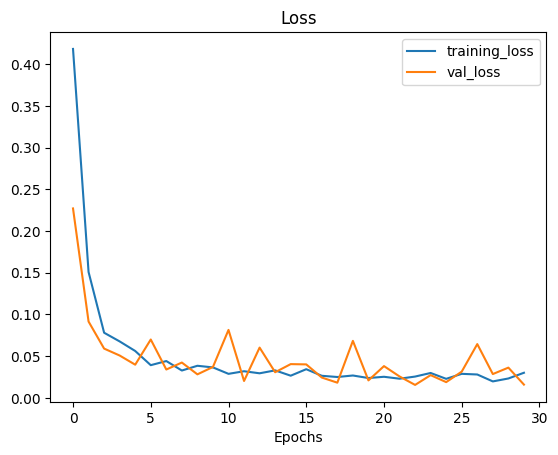

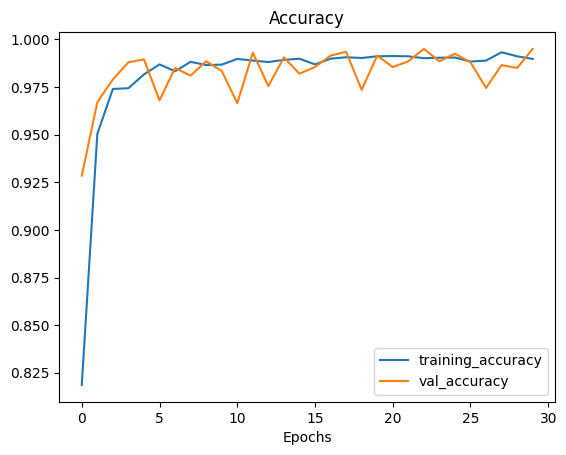

In [57]:
plot_loss_curves(history)

In [58]:
model.save('models/model2_99_01.h5')

In [59]:
# nmae of featues
feature_names = x.columns.tolist()
print("Feature names:", feature_names)

Feature names: ['length', 'diameter', 'mass', 'motor_thrust', 'burn_time', 'cg', 'cp', 'material']


In [76]:
import pandas as pd
import numpy as np

# --- Simulate external unseen test data ---
external_data = [
    {
        'length': 80,
        'diameter': 10,
        'mass': 2200,
        'motor_thrust': 3000,
        'burn_time': 3.0,
        'cg': 40.0,
        'cp': 47.0,
        'material': 1  # ✔️ Likely STABLE (good CG<CP margin)
    },
    {
        'length': 60,
        'diameter': 8,
        'mass': 1500,
        'motor_thrust': 2800,
        'burn_time': 2.5,
        'cg': 30.0,
        'cp': 28.0,
        'material': 0  # ❌ UNSTABLE (CG ahead of CP)
    },
    {
        'length': 100,
        'diameter': 12,
        'mass': 3000,
        'motor_thrust': 3200,
        'burn_time': 4.5,
        'cg': 48.0,
        'cp': 59.0,
        'material': 2  # ✔️ Likely STABLE (CG < CP by >10cm)
    },
    {
        'length': 70,
        'diameter': 9,
        'mass': 1400,
        'motor_thrust': 3100,
        'burn_time': 1.8,
        'cg': 34.5,
        'cp': 33.0,
        'material': 1  # ❌ UNSTABLE (CG > CP)
    },
    {
        'length': 90,
        'diameter': 11,
        'mass': 2500,
        'motor_thrust': 2900,
        'burn_time': 3.5,
        'cg': 43.0,
        'cp': 50.0,
        'material': 0  # ✔️ Likely STABLE
    },
    {
        'length': 50,
        'diameter': 6,
        'mass': 1000,
        'motor_thrust': 2700,
        'burn_time': 2.0,
        'cg': 26.0,
        'cp': 24.0,
        'material': 2  # ❌ UNSTABLE
    },
    {
        'length': 85,
        'diameter': 9,
        'mass': 2300,
        'motor_thrust': 3100,
        'burn_time': 4.0,
        'cg': 42.0,
        'cp': 51.0,
        'material': 1  # ✔️ STABLE
    },
    {
        'length': 75,
        'diameter': 10,
        'mass': 1800,
        'motor_thrust': 3500,
        'burn_time': 1.5,
        'cg': 36.0,
        'cp': 35.0,
        'material': 0  # ❌ UNSTABLE (CP too close or behind CG, high thrust)
    },
    {
        'length': 95,
        'diameter': 13,
        'mass': 2700,
        'motor_thrust': 2800,
        'burn_time': 4.2,
        'cg': 46.0,
        'cp': 57.0,
        'material': 2  # ✔️ Likely STABLE
    },
    {
        'length': 60,
        'diameter': 7,
        'mass': 1200,
        'motor_thrust': 3000,
        'burn_time': 1.8,
        'cg': 30.0,
        'cp': 27.0,
        'material': 1  # ❌ UNSTABLE
    }
]


df_external = pd.DataFrame(external_data)

# --- Map material to numeric codes as in your training data ---
# Find mapping from your training data
material_mapping = {v: k for k, v in dict(df2['material'].astype(int).value_counts().sort_index()).items()}
# If you know the mapping, you can hardcode it, e.g.:
# material_mapping = {'metal': 0, 'plastic': 1, 'wood': 2}
# Let's infer from df2 if possible:
unique_materials = df2[['material']].drop_duplicates().sort_values('material')
material_labels = ['metal', 'plastic', 'wood']  # adjust if you know the order
material_code_map = dict(zip(material_labels, unique_materials['material'].values))
df_external['material'] = df_external['material'].map(material_code_map)

# --- Use the same scaler as in training ---
from sklearn.preprocessing import MinMaxScaler

# Use the same columns as in training
feature_names = ['length', 'diameter', 'mass', 'motor_thrust', 'burn_time', 'cg', 'cp', 'material']

# Use the scaler already fitted on training data (variable: scaler)
X_external = df_external[feature_names].copy()
X_external[feature_names] = scaler.transform(X_external[feature_names])

# --- Predict with your trained model ---
predictions = model.predict(X_external)
predicted_classes = (predictions > 0.5).astype(int).flatten()

# --- Display results ---
for i, (input_row, pred, cls) in enumerate(zip(external_data, predictions, predicted_classes)):
    print(f"Rocket #{i+1}:")
    print(f"  Input: {input_row}")
    # print(f"  Probability Stable: {pred[0]:.3f}")
    print(f"  Predicted Class: {'Stable (1)' if cls == 1 else 'Unstable (0)'}\n")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Rocket #1:
  Input: {'length': 80, 'diameter': 10, 'mass': 2200, 'motor_thrust': 3000, 'burn_time': 3.0, 'cg': 40.0, 'cp': 47.0, 'material': 1}
  Predicted Class: Unstable (0)

Rocket #2:
  Input: {'length': 60, 'diameter': 8, 'mass': 1500, 'motor_thrust': 2800, 'burn_time': 2.5, 'cg': 30.0, 'cp': 28.0, 'material': 0}
  Predicted Class: Unstable (0)

Rocket #3:
  Input: {'length': 100, 'diameter': 12, 'mass': 3000, 'motor_thrust': 3200, 'burn_time': 4.5, 'cg': 48.0, 'cp': 59.0, 'material': 2}
  Predicted Class: Unstable (0)

Rocket #4:
  Input: {'length': 70, 'diameter': 9, 'mass': 1400, 'motor_thrust': 3100, 'burn_time': 1.8, 'cg': 34.5, 'cp': 33.0, 'material': 1}
  Predicted Class: Unstable (0)

Rocket #5:
  Input: {'length': 90, 'diameter': 11, 'mass': 2500, 'motor_thrust': 2900, 'burn_time': 3.5, 'cg': 43.0, 'cp': 50.0, 'material': 0}
  Predicted Class: Unstable (0)

Rocket #6:
  Input: {'length': 50, 'diameter': 6, 'mass': 1000, 'motor_thrust'

In [75]:
import pandas as pd
import numpy as np

# --- Simulate external unseen test data ---
external_data = [
    {
        'length': 80,
        'diameter': 10,
        'mass': 2200,
        'motor_thrust': 3000,
        'burn_time': 3.0,
        'cg': 40.0,
        'cp': 47.0,
        'material': 1  # ✔️ Likely STABLE (good CG<CP margin)
    },
    {
        'length': 60,
        'diameter': 8,
        'mass': 1500,
        'motor_thrust': 2800,
        'burn_time': 2.5,
        'cg': 30.0,
        'cp': 28.0,
        'material': 0  # ❌ UNSTABLE (CG ahead of CP)
    },
    {
        'length': 100,
        'diameter': 12,
        'mass': 3000,
        'motor_thrust': 3200,
        'burn_time': 4.5,
        'cg': 48.0,
        'cp': 59.0,
        'material': 2  # ✔️ Likely STABLE (CG < CP by >10cm)
    },
    {
        'length': 70,
        'diameter': 9,
        'mass': 1400,
        'motor_thrust': 3100,
        'burn_time': 1.8,
        'cg': 34.5,
        'cp': 33.0,
        'material': 1  # ❌ UNSTABLE (CG > CP)
    },
    {
        'length': 90,
        'diameter': 11,
        'mass': 2500,
        'motor_thrust': 2900,
        'burn_time': 3.5,
        'cg': 43.0,
        'cp': 50.0,
        'material': 0  # ✔️ Likely STABLE
    },
    {
        'length': 50,
        'diameter': 6,
        'mass': 1000,
        'motor_thrust': 2700,
        'burn_time': 2.0,
        'cg': 26.0,
        'cp': 24.0,
        'material': 2  # ❌ UNSTABLE
    },
    {
        'length': 85,
        'diameter': 9,
        'mass': 2300,
        'motor_thrust': 3100,
        'burn_time': 4.0,
        'cg': 42.0,
        'cp': 51.0,
        'material': 1  # ✔️ STABLE
    },
    {
        'length': 75,
        'diameter': 10,
        'mass': 1800,
        'motor_thrust': 3500,
        'burn_time': 1.5,
        'cg': 36.0,
        'cp': 35.0,
        'material': 0  # ❌ UNSTABLE (CP too close or behind CG, high thrust)
    },
    {
        'length': 95,
        'diameter': 13,
        'mass': 2700,
        'motor_thrust': 2800,
        'burn_time': 4.2,
        'cg': 46.0,
        'cp': 57.0,
        'material': 2  # ✔️ Likely STABLE
    },
    {
        'length': 60,
        'diameter': 7,
        'mass': 1200,
        'motor_thrust': 3000,
        'burn_time': 1.8,
        'cg': 30.0,
        'cp': 27.0,
        'material': 1  # ❌ UNSTABLE
    }
]


df_external = pd.DataFrame(external_data)

# --- Map material to numeric codes as in your training data ---
# Find mapping from your training data
material_mapping = {v: k for k, v in dict(df2['material'].astype(int).value_counts().sort_index()).items()}
# If you know the mapping, you can hardcode it, e.g.:
# material_mapping = {'metal': 0, 'plastic': 1, 'wood': 2}
# Let's infer from df2 if possible:
unique_materials = df2[['material']].drop_duplicates().sort_values('material')
material_labels = ['metal', 'plastic', 'wood']  # adjust if you know the order
material_code_map = dict(zip(material_labels, unique_materials['material'].values))
df_external['material'] = df_external['material'].map(material_code_map)

# --- Use the same scaler as in training ---
from sklearn.preprocessing import MinMaxScaler

# Use the same columns as in training
feature_names = ['length', 'diameter', 'mass', 'motor_thrust', 'burn_time', 'cg', 'cp', 'material']

# Use the scaler already fitted on training data (variable: scaler)
X_external = df_external[feature_names].copy()
X_external[feature_names] = scaler.transform(X_external[feature_names])

# --- Predict with your trained model ---
predictions = model3.predict(X_external)
predicted_classes = (predictions > 0.5).astype(int).flatten()

# --- Display results ---
for i, (input_row, pred, cls) in enumerate(zip(external_data, predictions, predicted_classes)):
    print(f"Rocket #{i+1}:")
    print(f"  Input: {input_row}")
    # print(f"  Probability Stable: {pred[0]:.3f}")
    print(f"  Predicted Class: {'Stable (1)' if cls == 1 else 'Unstable (0)'}\n")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Rocket #1:
  Input: {'length': 80, 'diameter': 10, 'mass': 2200, 'motor_thrust': 3000, 'burn_time': 3.0, 'cg': 40.0, 'cp': 47.0, 'material': 1}
  Predicted Class: Unstable (0)

Rocket #2:
  Input: {'length': 60, 'diameter': 8, 'mass': 1500, 'motor_thrust': 2800, 'burn_time': 2.5, 'cg': 30.0, 'cp': 28.0, 'material': 0}
  Predicted Class: Unstable (0)

Rocket #3:
  Input: {'length': 100, 'diameter': 12, 'mass': 3000, 'motor_thrust': 3200, 'burn_time': 4.5, 'cg': 48.0, 'cp': 59.0, 'material': 2}
  Predicted Class: Unstable (0)

Rocket #4:
  Input: {'length': 70, 'diameter': 9, 'mass': 1400, 'motor_thrust': 3100, 'burn_time': 1.8, 'cg': 34.5, 'cp': 33.0, 'material': 1}
  Predicted Class: Unstable (0)

Rocket #5:
  Input: {'length': 90, 'diameter': 11, 'mass': 2500, 'motor_thrust': 2900, 'burn_time': 3.5, 'cg': 43.0, 'cp': 50.0, 'material': 0}
  Predicted Class: Unstable (0)

Rocket #6:
  Input: {'length': 50, 'diameter': 6, 'mass': 1000, 'motor_thrust'